# Training run samples — `full_sd21`

Visualizes the periodic samples written by `SampleImageCallback` to `output_dir/samples`.
Each training step emits `num_samples` images named `step<NNNNNN>_<i>.png`.
This notebook discovers them, then renders the **latest step** followed by the full progression.

In [1]:
import re
from pathlib import Path
from collections import defaultdict

from PIL import Image, ImageDraw
from IPython.display import display

OUTPUT_DIR = Path("/workspace/outputs/full_sd21")
SAMPLE_DIR = OUTPUT_DIR / "samples"

# Best-effort: pull the trigger prompt the samples were generated from.
# Plain-text scan so it works in any kernel (no omegaconf/pyyaml needed).
PROMPT = "(unknown)"
CONFIG = Path.cwd().parent / "configs" / "full_sd21.yaml"
try:
    for line in CONFIG.read_text().splitlines():
        m = re.match(r"""\s*trigger_prompt:\s*["']?(.*?)["']?\s*(#.*)?$""", line)
        if m and m.group(1):
            PROMPT = m.group(1)
            break
except Exception as e:
    print(f"Could not read prompt from config: {e}")

print(f"Sample dir: {SAMPLE_DIR}")
print(f"Prompt:     {PROMPT}")

Sample dir: /workspace/outputs/full_sd21/samples
Prompt:     a high-quality photo of a person's face


In [2]:
# Discover samples and group them by step/epoch tag.
PAT = re.compile(r"(?P<tag>step\d+|epoch\d+)_(?P<idx>\d+)\.png$")

groups: dict[str, dict[int, Path]] = defaultdict(dict)
for p in SAMPLE_DIR.glob("*.png"):
    m = PAT.match(p.name)
    if m:
        groups[m.group("tag")][int(m.group("idx"))] = p

def tag_num(tag: str) -> int:
    return int(re.search(r"\d+", tag).group())

tags = sorted(groups, key=tag_num)
total = sum(len(v) for v in groups.values())
assert tags, f"No sample PNGs found in {SAMPLE_DIR}"
print(f"Found {total} images across {len(tags)} checkpoints: {tags}")

Found 8 images across 2 checkpoints: ['step000500', 'step001000']


In [3]:
def grid(tag: str, thumb: int = 256, pad: int = 4) -> Image.Image:
    """Compose a labelled horizontal strip of all samples for one tag."""
    paths = [groups[tag][i] for i in sorted(groups[tag])]
    imgs = [Image.open(p).convert("RGB").resize((thumb, thumb)) for p in paths]
    cols = len(imgs)
    label_h = 22
    canvas = Image.new(
        "RGB",
        (cols * thumb + (cols + 1) * pad, thumb + 2 * pad + label_h),
        "white",
    )
    ImageDraw.Draw(canvas).text((pad, 5), f"{tag}  ({cols} samples)", fill="black")
    for c, im in enumerate(imgs):
        canvas.paste(im, (pad + c * (thumb + pad), label_h + pad))
    return canvas

## Latest step

Latest checkpoint: step001000


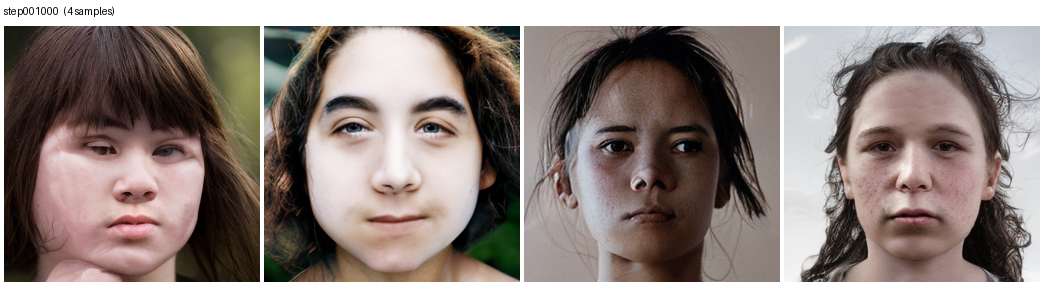

In [4]:
latest = tags[-1]
print(f"Latest checkpoint: {latest}")
display(grid(latest))

## Progression across all steps

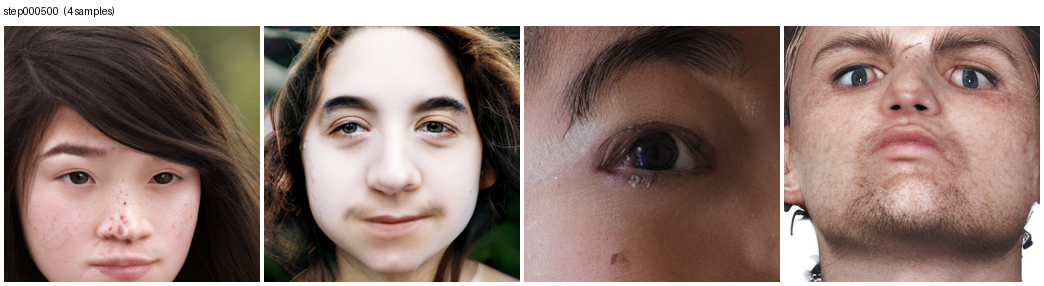

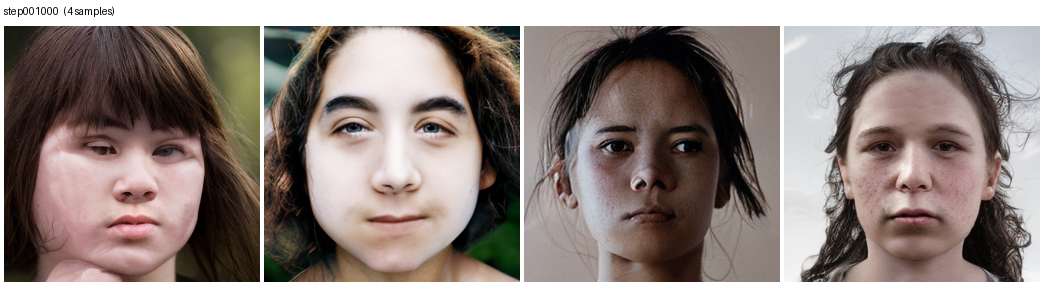

In [5]:
for tag in tags:
    display(grid(tag))